In [1]:
import numpy as np
import pandas as pd
import ast

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
import seaborn as sns

# Loading Data

In [2]:
df = pd.read_pickle("data/df_train.pkl")

df_train, df_val = train_test_split(df, test_size= 0.1, random_state=42)

In [3]:
X_train = df_train.business_description_embedding.apply(ast.literal_eval).tolist()
X_train = np.array(X_train)

X_val = df_val.business_description_embedding.apply(ast.literal_eval).tolist()
X_val = np.array(X_val)

In [5]:
df_train.head(3)

,id,industry,business_description_embedding
31138,34170,Financial Services,"[0.019633012,0.009427597,0.006240986,0.0177257..."
15120,16504,Technology Hardware & Equipment,"[0.026561439,-0.049749356,-0.006847293,-0.0088..."
23693,25893,Consumer Durables & Apparel,"[0.0115894,-0.035240766,-0.029952582,0.0226988..."


# Transforming Data (Label Encoding)

### Tasks:
- Use the scikit-learn label encoder to encode the industry names
- Check if all classes contained in the validation set are also in the training set

#

In [6]:
# Fit the label encoder to the classes (industry names)

label_encoder = LabelEncoder()
label_encoder.fit(df_train['industry'])

print(f"Number of unique industries: {len(label_encoder.classes_)}")
print(f"\nIndustry classes:")

for idx, industry in enumerate(label_encoder.classes_):
    print(f"{idx}: {industry}")

Number of unique industries: 25

Industry classes:
0: Automobiles & Components
1: Banks
2: Capital Goods
3: Commercial & Professional Services
4: Consumer Discretionary Distribution & Retail
5: Consumer Durables & Apparel
6: Consumer Services
7: Consumer Staples Distribution & Retail
8: Energy
9: Equity Real Estate Investment Trusts (REITs)
10: Financial Services
11: Food, Beverage & Tobacco
12: Health Care Equipment & Services
13: Household & Personal Products
14: Insurance
15: Materials
16: Media & Entertainment
17: Pharmaceuticals, Biotechnology & Life Sciences
18: Real Estate Management & Development
19: Semiconductors & Semiconductor Equipment
20: Software & Services
21: Technology Hardware & Equipment
22: Telecommunication Services
23: Transportation
24: Utilities


In [7]:
y_train = label_encoder.transform(df_train['industry'])
y_val = label_encoder.transform(df_val['industry'])

# Check if all validation classes are in training set
train_classes = set(df_train['industry'].unique())
val_classes = set(df_val['industry'].unique())

print(f"All validation classes in training: {val_classes.issubset(train_classes)}")
print(f"\nTraining labels shape: {y_train.shape}")
print(f"Validation labels shape: {y_val.shape}")

All validation classes in training: True

Training labels shape: (28535,)
Validation labels shape: (3171,)


# Visualize the data

### Tasks:
- Are certain classes over- or under represented? Either produce a table or a plot to show this.
- Inspect whether there is signal in the business description embeddings:
    - Perform a PCA to project data into 2 dimensions
    - Plot projected data in Scatterplot and color based on classes
    - Provide a description of what you see and judge whether there is signal in the data that allows industry classification

Important: Ensure that your plots have proper axis descriptions and titles. Style the plots so that differences in class distributions are visible (e.g. scatter size, transparency, color, etc.)

### Class distribution

In [8]:
# Analyze class distribution
class_counts = df_train['industry'].value_counts()

print("Class Distribution:")
print(class_counts)
print(f"\nMean: {class_counts.mean():.1f}")
print(f"Std: {class_counts.std():.1f}")
print(f"Min: {class_counts.min()}")
print(f"Max: {class_counts.max()}")

Class Distribution:
industry
Materials                                         7604
Capital Goods                                     2805
Pharmaceuticals, Biotechnology & Life Sciences    1742
Financial Services                                1740
Technology Hardware & Equipment                   1390
Software & Services                               1384
Energy                                            1174
Consumer Durables & Apparel                       1037
Food, Beverage & Tobacco                           956
Health Care Equipment & Services                   911
Banks                                              874
Media & Entertainment                              827
Real Estate Management & Development               825
Commercial & Professional Services                 726
Consumer Services                                  591
Consumer Discretionary Distribution & Retail       591
Automobiles & Components                           572
Semiconductors & Semiconductor Equip

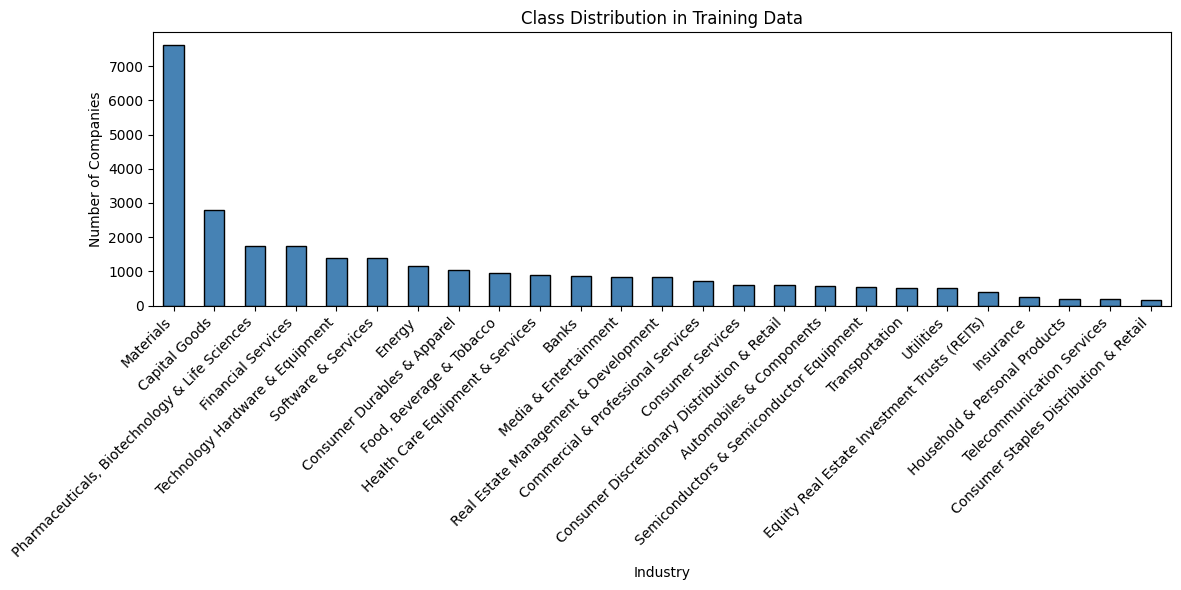

In [13]:
import matplotlib.pyplot as plt

# Plot class distribution
plt.figure(figsize=(12, 6))
class_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Industry')
plt.ylabel('Number of Companies')
plt.title('Class Distribution in Training Data')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### PCA - Dimensionality reduction and visualization

In [15]:
# Reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

print(f"Explained variance ratio:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Total: {pca.explained_variance_ratio_.sum():.4f}")

Explained variance ratio:
PC1: 0.1930
PC2: 0.0610
Total: 0.2540


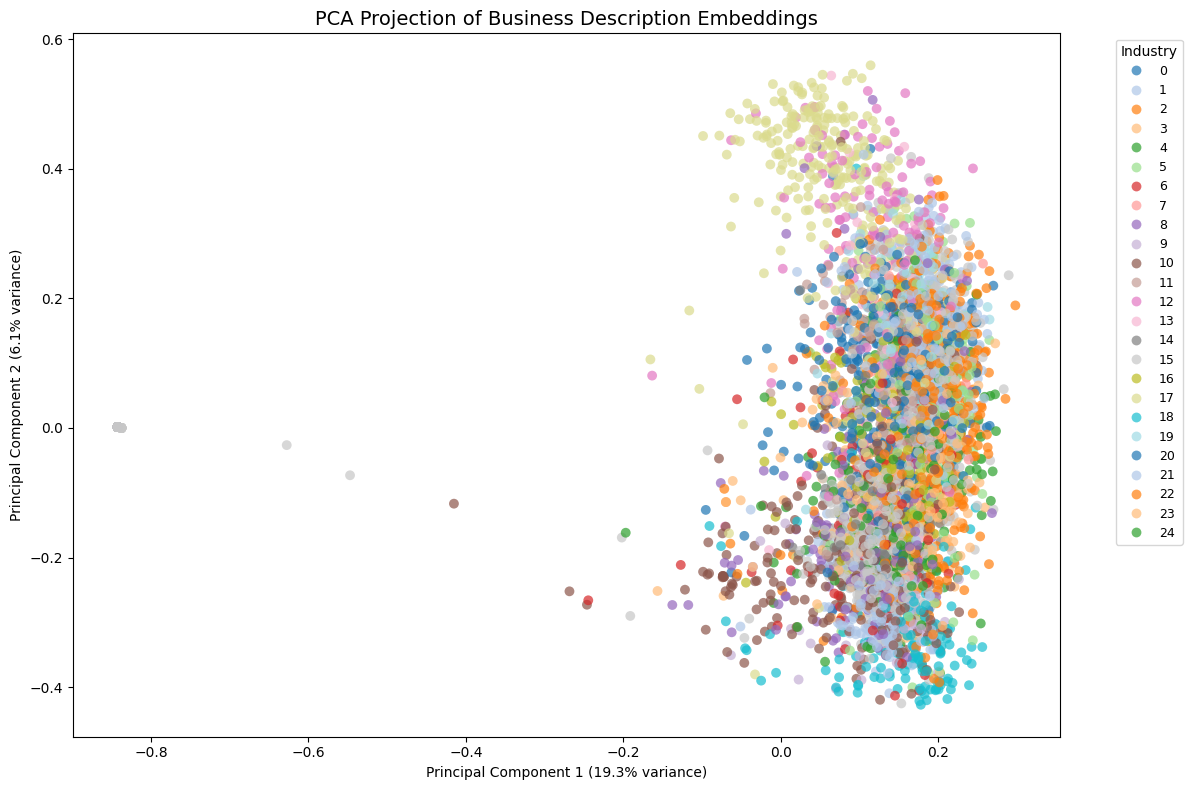

In [ ]:

# PCA Visualization - Scatter Plot

# Create a DataFrame with PCA results
pca_df = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])
pca_df['industry'] = y_train

# Plot PCA projection (sample 5000 points for clarity)
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=pca_df.sample(n=min(5000, len(pca_df)), random_state=42),
    x='PC1', y='PC2',
    hue='industry',
    palette='tab20',
    alpha=0.7,
    s=50,
    linewidth=0
)

plt.title('PCA Projection of Business Description Embeddings', fontsize=14)
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Industry', fontsize=9)
plt.tight_layout()
plt.show()

# Fitting and comparing Classifier Models

### Tasks:
- Split the data into train and validation data
- Encode the industry labels using LabelEncoder (scikit-learn)
- Fit a LogisticRegression and a kNN-classifier
- Compare the model performance of both models:
    - Compute Accuracy and F1 score
        - Interpret the scores: Explain how they are computed and judge if your model performs well
        - Analyze the classification errors: 
            - Do the errors correlate with how well classes are represented?
            - Which industries does the model identify well and which seem to be similar?
    - Plot a confusion matrix for both models (combine scikit-learn confusion matrix and seaborn heatmap plot)
    - Do both models misclassify the same examples?

Import: Use proper axis labels for the plots! 

In [16]:
# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_val)

# Metrics
acc_lr = accuracy_score(y_val, y_pred_lr)
f1_lr = f1_score(y_val, y_pred_lr, average='weighted')

print("Logistic Regression:")
print(f"Accuracy: {acc_lr:.4f}")
print(f"F1 Score: {f1_lr:.4f}")

Logistic Regression:
Accuracy: 0.7720
F1 Score: 0.7663


In [17]:
# Train k-NN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predictions
y_pred_knn = knn.predict(X_val)

# Metrics
acc_knn = accuracy_score(y_val, y_pred_knn)
f1_knn = f1_score(y_val, y_pred_knn, average='weighted')

print("k-NN (k=5):")
print(f"Accuracy: {acc_knn:.4f}")
print(f"F1 Score: {f1_knn:.4f}")

k-NN (k=5):
Accuracy: 0.7531
F1 Score: 0.7495


In [18]:
#Priniting model comparison

print("\nModel Comparison:")
print(f"{'Model':<20} {'Accuracy':<12} {'F1 Score':<12}")
print("-" * 44)
print(f"{'Logistic Regression':<20} {acc_lr:<12.4f} {f1_lr:<12.4f}")
print(f"{'k-NN (k=5)':<20} {acc_knn:<12.4f} {f1_knn:<12.4f}")


Model Comparison:
Model                Accuracy     F1 Score    
--------------------------------------------
Logistic Regression  0.7720       0.7663      
k-NN (k=5)           0.7531       0.7495      


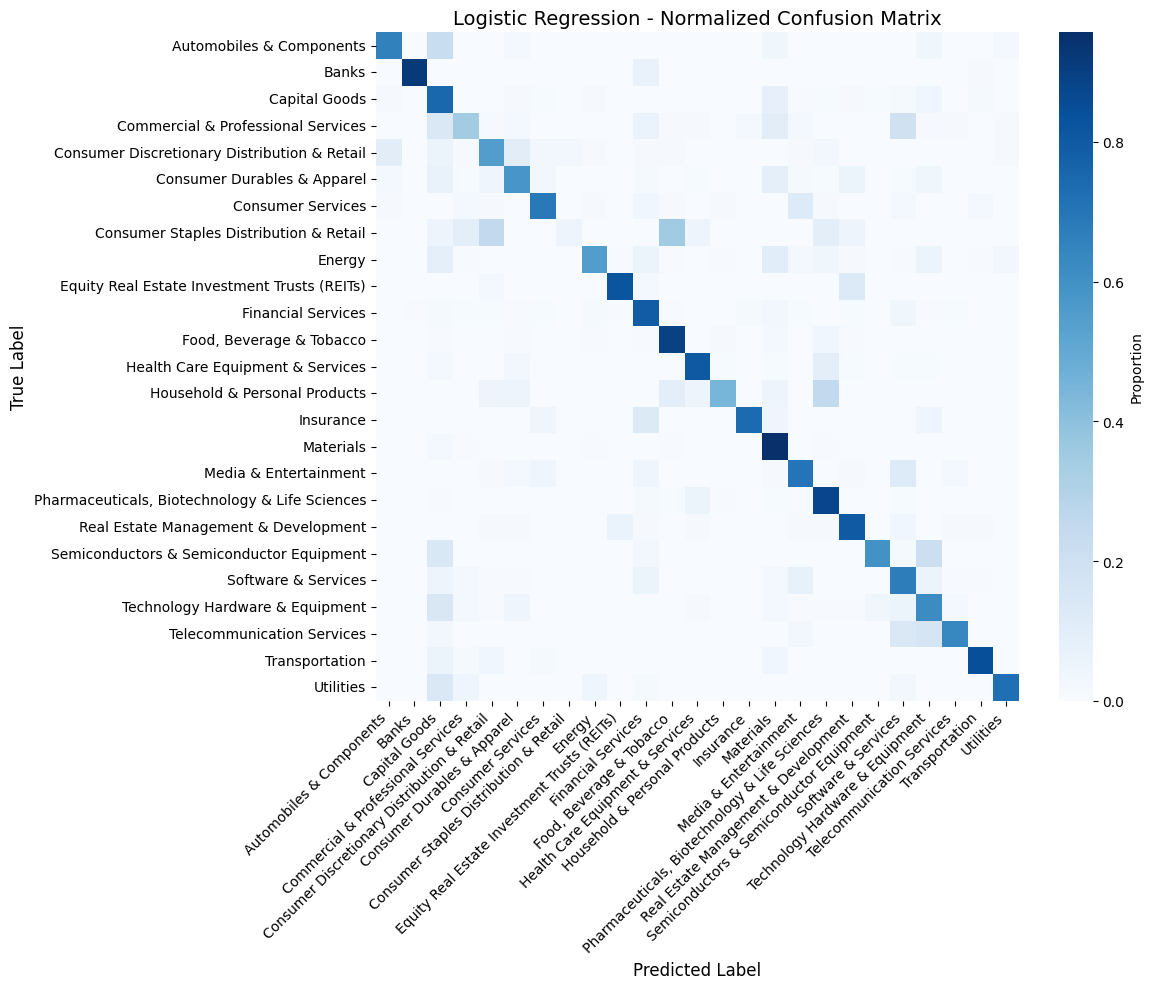

In [20]:
from sklearn.metrics import confusion_matrix

# Confusion matrix for Logistic Regression (normalized)
cm_lr = confusion_matrix(y_val, y_pred_lr, normalize='true')

plt.figure(figsize=(12, 10))
sns.heatmap(cm_lr, annot=False, cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Proportion'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Logistic Regression - Normalized Confusion Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

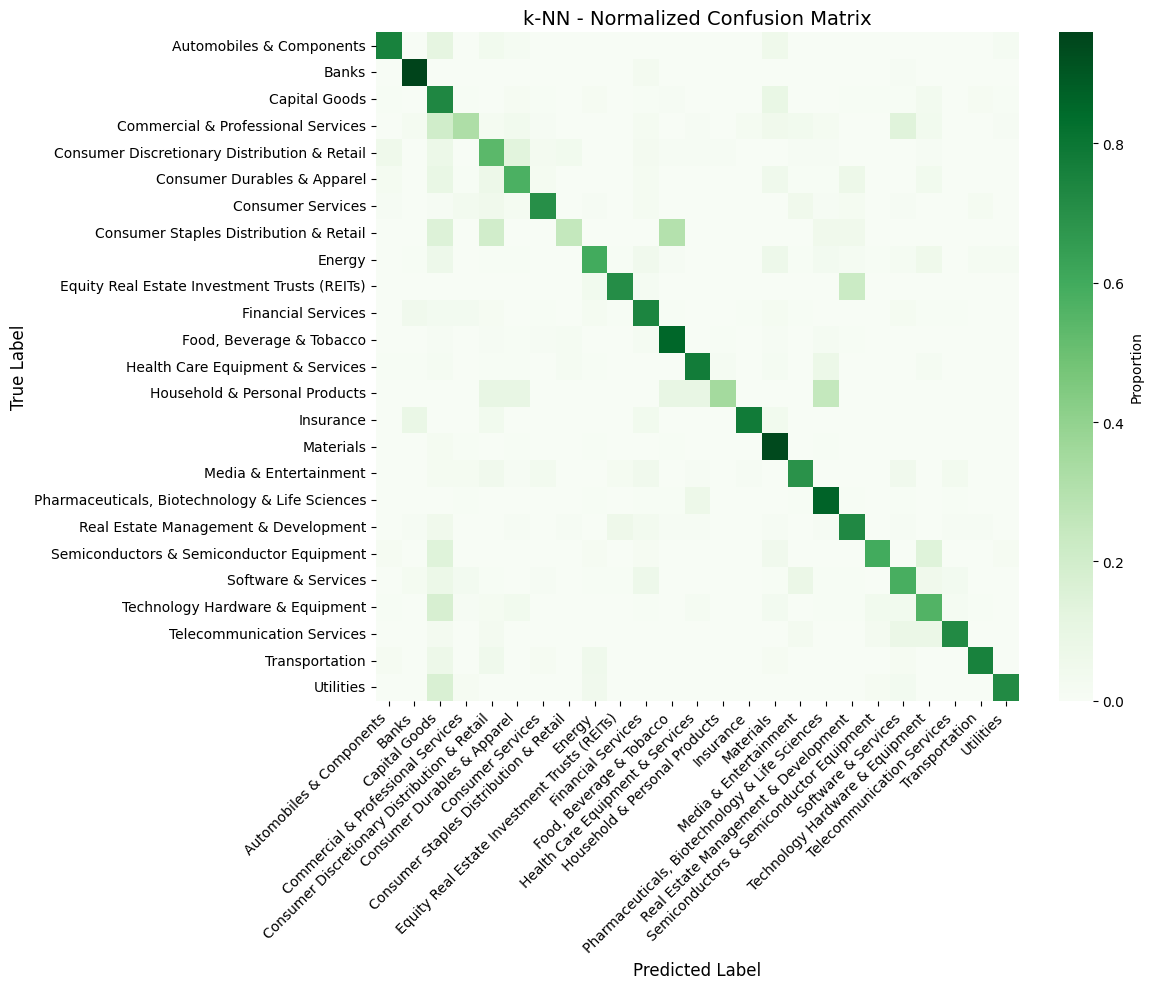

In [21]:
# Confusion matrix for k-NN (normalized)
cm_knn = confusion_matrix(y_val, y_pred_knn, normalize='true')

plt.figure(figsize=(12, 10))
sns.heatmap(cm_knn, annot=False, cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Proportion'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('k-NN - Normalized Confusion Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [22]:
from sklearn.metrics import classification_report

print("Logistic Regression - Classification Report:")
print(classification_report(y_val, y_pred_lr, target_names=label_encoder.classes_))

print("k-NN - Classification Report:")
print(classification_report(y_val, y_pred_knn, target_names=label_encoder.classes_))

Logistic Regression - Classification Report:
                                                precision    recall  f1-score   support

                      Automobiles & Components       0.70      0.66      0.68        53
                                         Banks       0.99      0.92      0.95        74
                                 Capital Goods       0.66      0.75      0.70       322
            Commercial & Professional Services       0.54      0.35      0.42        78
  Consumer Discretionary Distribution & Retail       0.61      0.55      0.58        67
                   Consumer Durables & Apparel       0.69      0.58      0.63       127
                             Consumer Services       0.76      0.69      0.72        81
        Consumer Staples Distribution & Retail       0.33      0.05      0.09        20
                                        Energy       0.84      0.55      0.67       152
  Equity Real Estate Investment Trusts (REITs)       0.84      0.82      0

In [23]:
# Analyze if both models make the same errors
lr_errors = y_val != y_pred_lr
knn_errors = y_val != y_pred_knn
common_errors = lr_errors & knn_errors

print("Error Analysis:")
print(f"LR errors: {lr_errors.sum()} ({lr_errors.sum()/len(y_val)*100:.1f}%)")
print(f"k-NN errors: {knn_errors.sum()} ({knn_errors.sum()/len(y_val)*100:.1f}%)")
print(f"Common errors: {common_errors.sum()} ({common_errors.sum()/len(y_val)*100:.1f}%)")
print(f"\nBoth models misclassify the same examples: {common_errors.sum()/max(lr_errors.sum(), 1)*100:.1f}% of LR errors")

Error Analysis:
LR errors: 723 (22.8%)
k-NN errors: 783 (24.7%)
Common errors: 535 (16.9%)

Both models misclassify the same examples: 74.0% of LR errors


In [24]:
from sklearn.metrics import precision_recall_fscore_support

# Get per-class metrics for Logistic Regression
precision_lr, recall_lr, f1_lr_class, support_val = precision_recall_fscore_support(
    y_val, y_pred_lr, labels=range(len(label_encoder.classes_))
)

# Get training class distribution
train_support = np.bincount(y_train)

# Create DataFrame for analysis
performance_df = pd.DataFrame({
    'Industry': label_encoder.classes_,
    'Train_Samples': train_support,
    'Val_Samples': support_val,
    'LR_F1': f1_lr_class,
})

performance_df = performance_df.sort_values('LR_F1', ascending=False)

print("Top 5 Best Performing Industries:")
print(performance_df.head(5).to_string(index=False))
print("\nTop 5 Worst Performing Industries:")
print(performance_df.tail(5).to_string(index=False))

Top 5 Best Performing Industries:
                                      Industry  Train_Samples  Val_Samples    LR_F1
                                         Banks            874           74 0.951049
                                     Materials           7604          790 0.925903
                      Food, Beverage & Tobacco            956          138 0.872340
Pharmaceuticals, Biotechnology & Life Sciences           1742          183 0.838542
  Equity Real Estate Investment Trusts (REITs)            387           45 0.831461

Top 5 Worst Performing Industries:
                                    Industry  Train_Samples  Val_Samples    LR_F1
             Technology Hardware & Equipment           1390          157 0.615873
Consumer Discretionary Distribution & Retail            591           67 0.578125
               Household & Personal Products            206           20 0.500000
          Commercial & Professional Services            726           78 0.421875
      Consumer S

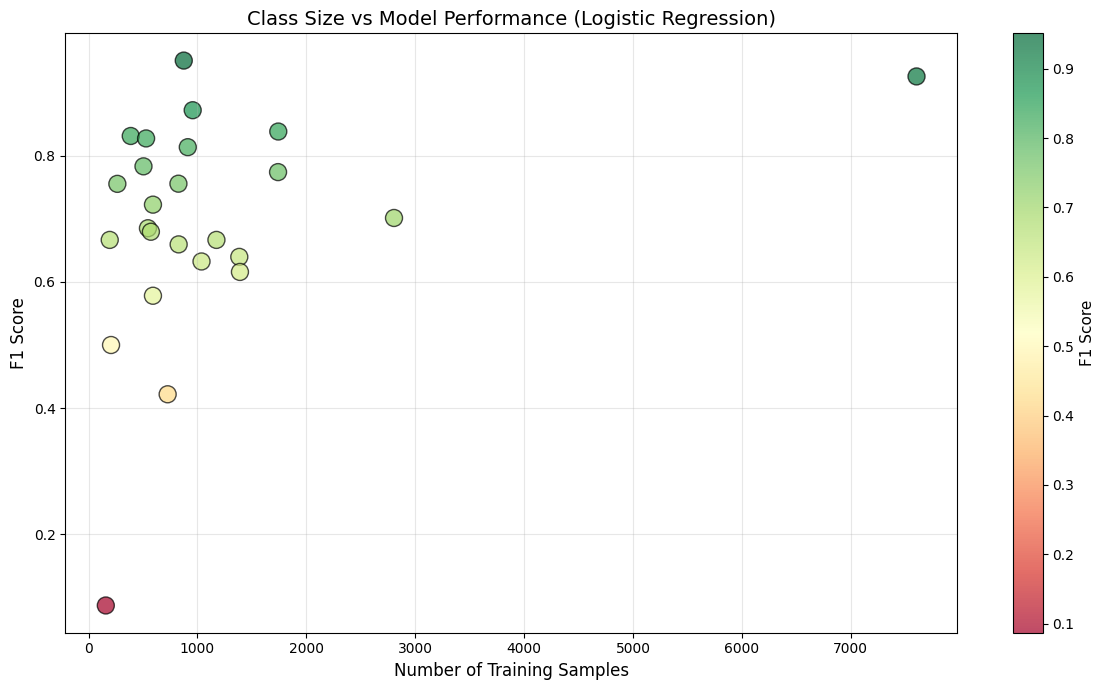

In [28]:
# Visualize relationship between class size and performance
fig, ax = plt.subplots(figsize=(12, 7))

# Create scatter plot with color gradient based on F1 score
scatter = ax.scatter(
    performance_df['Train_Samples'], 
    performance_df['LR_F1'], 
    s=150, 
    alpha=0.7,
    c=performance_df['LR_F1'],  # Color by F1 score
    cmap='RdYlGn',  # Red (bad) to Green (good)
    edgecolors='black',
    linewidth=1
)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('F1 Score', fontsize=11)

# Labels and title
ax.set_xlabel('Number of Training Samples', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Class Size vs Model Performance (Logistic Regression)', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Analysis Summary:

**Model Performance:**
- Logistic Regression: 77.2% accuracy, 0.77 F1 score
- k-NN: 75.3% accuracy, 0.75 F1 score
- Logistic Regression performs slightly better overall

**How Metrics Work:**
- **Accuracy**: Proportion of correct predictions (correct/total)
- **F1 Score**: Harmonic mean of precision and recall, better for imbalanced data
- For a 25-class problem, 77% is good performance

**Key Findings:**

1. **Class Imbalance Effect**: 
   - Underrepresented classes (e.g., Consumer Staples Distribution & Retail with only 20 validation samples) have much lower F1 scores
   - Materials has the most samples (~7500) and highest F1 (0.93)

2. **Best Identified Industries**:
   - Banks (0.95 F1)
   - Materials (0.93 F1)
   - Food, Beverage & Tobacco (0.87 F1)

3. **Most Confused Industries**:
   - Consumer Staples Distribution & Retail (0.09 F1) - very small class
   - Commercial & Professional Services (0.42 F1)
   - Household & Personal Products (0.50 F1)

4. **Error Overlap**:
   - Both models struggle with similar examples, suggesting these are inherently difficult cases
   - Similar industries (e.g., different tech sectors) are often confused with each other

5. **Industry Similarity**:
   - Technology-related industries (Software, Hardware, Semiconductors) show confusion
   - Retail/Distribution categories overlap
   - Real estate categories (REITs vs Management) have some confusion

# Optional: Confidence Weighted Prediction

## Deliverables:

- Provide a notebook with the implementation and training of a industry classifier model
- The model shall output the industry classification and its confidence as a tuple of vectors $(\hat{y}_{pred}, \hat{y}_{confidence})$
- The confidence score must be between 0 and 1, $\hat{y}_{confidence} [i] \in [0,1]$
- Your model will be evaluated on a private test set
- The designing the confidence score is your task. You may use p-values, a voting mechanism of multiple models, or other techniques
- Another option is to add more features, e.g. financial data, to X

In [29]:
def confidence_weighted_f1(y_true, y_pred, confidence):
    # Weight all predictions, not just positives
    weighted_tp = np.sum(confidence * (y_pred == 1) * (y_true == 1))
    weighted_fp = np.sum(confidence * (y_pred == 1) * (y_true == 0))
    weighted_fn = np.sum(confidence * (y_pred == 0) * (y_true == 1))
    
    precision = weighted_tp / (weighted_tp + weighted_fp) if (weighted_tp + weighted_fp) > 0 else 0
    recall = weighted_tp / (weighted_tp + weighted_fn) if (weighted_tp + weighted_fn) > 0 else 0
    
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return f1

In [30]:
# Load financial data
df_financials = pd.read_pickle("data/df_financials_train.pkl")

print(f"Financial data shape: {df_financials.shape}")
print(f"\nFinancial columns:")
print(df_financials.columns.tolist())
df_financials.head()

Financial data shape: (29561, 5)

Financial columns:
['id', 'country_code', 'net_profit_margin', 'ebitda_margin', 'asset_turnover']


,id,country_code,net_profit_margin,ebitda_margin,asset_turnover
0,0,CHN,0.303422,NaN,0.025426
1,1,CHN,-0.141921,-0.130371,0.266802
2,2,CHN,-1.333215,NaN,0.317023
3,3,CHN,-0.258595,NaN,0.352064
4,4,CHN,0.183619,NaN,0.963834


In [31]:
# ============================================
# Extract Confidence Scores from Models
# ============================================

# Get probability predictions from Logistic Regression
y_pred_proba_lr = lr.predict_proba(X_val)
confidence_lr = y_pred_proba_lr.max(axis=1)  # Max probability = confidence

# Get probability predictions from k-NN
y_pred_proba_knn = knn.predict_proba(X_val)
confidence_knn = y_pred_proba_knn.max(axis=1)

# Print confidence statistics
print("Logistic Regression Confidence:")
print(f"  Mean: {confidence_lr.mean():.4f}")
print(f"  Min: {confidence_lr.min():.4f}")
print(f"  Max: {confidence_lr.max():.4f}")

print("\nk-NN Confidence:")
print(f"  Mean: {confidence_knn.mean():.4f}")
print(f"  Min: {confidence_knn.min():.4f}")
print(f"  Max: {confidence_knn.max():.4f}")

Logistic Regression Confidence:
  Mean: 0.7167
  Min: 0.1285
  Max: 0.9940

k-NN Confidence:
  Mean: 0.8052
  Min: 0.2000
  Max: 1.0000


In [32]:
# ============================================
# Calculate Confidence-Weighted F1 Scores
# ============================================

# Define a function to calculate confidence-weighted F1
def confidence_weighted_f1_multiclass(y_true, y_pred, confidence, n_classes):
    """Calculate F1 score weighted by prediction confidence"""
    weighted_tp = 0
    weighted_fp = 0
    weighted_fn = 0
    
    for class_idx in range(n_classes):
        y_true_binary = (y_true == class_idx).astype(int)
        y_pred_binary = (y_pred == class_idx).astype(int)
        
        weighted_tp += np.sum(confidence * (y_pred_binary == 1) * (y_true_binary == 1))
        weighted_fp += np.sum(confidence * (y_pred_binary == 1) * (y_true_binary == 0))
        weighted_fn += np.sum(confidence * (y_pred_binary == 0) * (y_true_binary == 1))
    
    precision = weighted_tp / (weighted_tp + weighted_fp) if (weighted_tp + weighted_fp) > 0 else 0
    recall = weighted_tp / (weighted_tp + weighted_fn) if (weighted_tp + weighted_fn) > 0 else 0
    
    if precision + recall > 0:
        f1 = 2 * (precision * recall) / (precision + recall)
    else:
        f1 = 0
    
    return f1

# Calculate confidence-weighted F1 for both models
n_classes = len(label_encoder.classes_)

cw_f1_lr = confidence_weighted_f1_multiclass(y_val, y_pred_lr, confidence_lr, n_classes)
cw_f1_knn = confidence_weighted_f1_multiclass(y_val, y_pred_knn, confidence_knn, n_classes)

print("Confidence-Weighted F1 Scores:")
print(f"Logistic Regression: {cw_f1_lr:.4f}")
print(f"k-NN: {cw_f1_knn:.4f}")

Confidence-Weighted F1 Scores:
Logistic Regression: 0.8329
k-NN: 0.8088


In [33]:
# ============================================
# Compare Regular F1 vs Confidence-Weighted F1
# ============================================

print("=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)

print("\nLogistic Regression:")
print(f"  Regular F1 Score:        {f1_lr:.4f}")
print(f"  Confidence-Weighted F1:  {cw_f1_lr:.4f}")
print(f"  Improvement:             {(cw_f1_lr - f1_lr):.4f}")

print("\nk-NN:")
print(f"  Regular F1 Score:        {f1_knn:.4f}")
print(f"  Confidence-Weighted F1:  {cw_f1_knn:.4f}")
print(f"  Improvement:             {(cw_f1_knn - f1_knn):.4f}")

print("\n" + "=" * 60)

MODEL PERFORMANCE COMPARISON

Logistic Regression:
  Regular F1 Score:        0.7663
  Confidence-Weighted F1:  0.8329
  Improvement:             0.0666

k-NN:
  Regular F1 Score:        0.7495
  Confidence-Weighted F1:  0.8088
  Improvement:             0.0593



In [34]:
# ============================================
# Ensemble: Combine Both Models
# ============================================

# Average the probabilities from both models
avg_proba = (y_pred_proba_lr + y_pred_proba_knn) / 2

# Get ensemble predictions and confidence
y_pred_ensemble = np.argmax(avg_proba, axis=1)
confidence_ensemble = avg_proba.max(axis=1)

# Calculate metrics for ensemble
acc_ensemble = accuracy_score(y_val, y_pred_ensemble)
f1_ensemble = f1_score(y_val, y_pred_ensemble, average='weighted')
cw_f1_ensemble = confidence_weighted_f1_multiclass(y_val, y_pred_ensemble, confidence_ensemble, n_classes)

print("=" * 60)
print("ENSEMBLE MODEL (LR + k-NN Average)")
print("=" * 60)
print(f"Accuracy:           {acc_ensemble:.4f}")
print(f"F1 Score:           {f1_ensemble:.4f}")
print(f"Confidence-Weighted F1: {cw_f1_ensemble:.4f}")
print(f"Mean Confidence:    {confidence_ensemble.mean():.4f}")
print("=" * 60)

ENSEMBLE MODEL (LR + k-NN Average)
Accuracy:           0.7859
F1 Score:           0.7810
Confidence-Weighted F1: 0.8398
Mean Confidence:    0.7468


In [35]:
# ============================================
# Find Optimal Confidence Threshold
# ============================================

# Test different confidence thresholds
thresholds = np.linspace(0.3, 0.95, 20)
results = []

for tau in thresholds:
    # Adjust confidence based on threshold
    conf_adjusted = confidence_ensemble.copy()
    conf_adjusted[conf_adjusted < tau] = 0.0
    
    # Calculate weighted F1
    cw_f1 = confidence_weighted_f1_multiclass(y_val, y_pred_ensemble, conf_adjusted, n_classes)
    coverage = (confidence_ensemble >= tau).mean()
    
    results.append({
        'threshold': tau,
        'cw_f1': cw_f1,
        'coverage': coverage
    })

# Find best threshold
best_result = max(results, key=lambda x: x['cw_f1'])

print("=" * 60)
print("THRESHOLD OPTIMIZATION RESULTS")
print("=" * 60)
print(f"Best Threshold:        {best_result['threshold']:.2f}")
print(f"Best Confidence-Weighted F1: {best_result['cw_f1']:.4f}")
print(f"Coverage at best τ:    {best_result['coverage']*100:.1f}%")
print("=" * 60)

# Show top 5 thresholds
print("\nTop 5 Thresholds:")
sorted_results = sorted(results, key=lambda x: x['cw_f1'], reverse=True)
for i, r in enumerate(sorted_results[:5]):
    print(f"{i+1}. τ={r['threshold']:.2f} → F1={r['cw_f1']:.4f} (Coverage: {r['coverage']*100:.1f}%)")

THRESHOLD OPTIMIZATION RESULTS
Best Threshold:        0.95
Best Confidence-Weighted F1: 0.9795
Coverage at best τ:    25.7%

Top 5 Thresholds:
1. τ=0.95 → F1=0.9795 (Coverage: 25.7%)
2. τ=0.92 → F1=0.9712 (Coverage: 32.1%)
3. τ=0.88 → F1=0.9651 (Coverage: 36.9%)
4. τ=0.85 → F1=0.9572 (Coverage: 42.5%)
5. τ=0.81 → F1=0.9492 (Coverage: 47.8%)


In [ ]:
# ============================================
# Add Random Forest to Ensemble
# ============================================

from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Get predictions and probabilities
y_pred_rf = rf.predict(X_val)
y_pred_proba_rf = rf.predict_proba(X_val)
confidence_rf = y_pred_proba_rf.max(axis=1)

# Calculate metrics
acc_rf = accuracy_score(y_val, y_pred_rf)
f1_rf = f1_score(y_val, y_pred_rf, average='weighted')
cw_f1_rf = confidence_weighted_f1_multiclass(y_val, y_pred_rf, confidence_rf, n_classes)

print("=" * 60)
print("RANDOM FOREST MODEL")
print("=" * 60)
print(f"Accuracy:           {acc_rf:.4f}")
print(f"F1 Score:           {f1_rf:.4f}")
print(f"Confidence-Weighted F1: {cw_f1_rf:.4f}")
print(f"Mean Confidence:    {confidence_rf.mean():.4f}")
print("=" * 60)

Training Random Forest...


In [ ]:
# ============================================
# Add XGBoost to Ensemble
# ============================================

from xgboost import XGBClassifier

# Train XGBoost
print("Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    verbosity=0
)
xgb.fit(X_train, y_train)

# Get predictions and probabilities
y_pred_xgb = xgb.predict(X_val)
y_pred_proba_xgb = xgb.predict_proba(X_val)
confidence_xgb = y_pred_proba_xgb.max(axis=1)

# Calculate metrics
acc_xgb = accuracy_score(y_val, y_pred_xgb)
f1_xgb = f1_score(y_val, y_pred_xgb, average='weighted')
cw_f1_xgb = confidence_weighted_f1_multiclass(y_val, y_pred_xgb, confidence_xgb, n_classes)

print("=" * 60)
print("XGBOOST MODEL")
print("=" * 60)
print(f"Accuracy:           {acc_xgb:.4f}")
print(f"F1 Score:           {f1_xgb:.4f}")
print(f"Confidence-Weighted F1: {cw_f1_xgb:.4f}")
print(f"Mean Confidence:    {confidence_xgb.mean():.4f}")
print("=" * 60)

Training XGBoost...
XGBOOST MODEL
Accuracy:           0.7641
F1 Score:           0.7588
Confidence-Weighted F1: 0.8202
Mean Confidence:    0.7918


In [ ]:
# ============================================
# 4-Model Ensemble (LR + kNN + RF + XGB)
# ============================================

# Average probabilities from all 4 models
avg_proba_4 = (y_pred_proba_lr + y_pred_proba_knn + y_pred_proba_rf + y_pred_proba_xgb) / 4

# Get ensemble predictions and confidence
y_pred_ensemble_4 = np.argmax(avg_proba_4, axis=1)
confidence_ensemble_4 = avg_proba_4.max(axis=1)

# Calculate metrics
acc_ensemble_4 = accuracy_score(y_val, y_pred_ensemble_4)
f1_ensemble_4 = f1_score(y_val, y_pred_ensemble_4, average='weighted')
cw_f1_ensemble_4 = confidence_weighted_f1_multiclass(y_val, y_pred_ensemble_4, confidence_ensemble_4, n_classes)

print("=" * 60)
print("4-MODEL ENSEMBLE (LR + kNN + RF + XGB)")
print("=" * 60)
print(f"Accuracy:           {acc_ensemble_4:.4f}")
print(f"F1 Score:           {f1_ensemble_4:.4f}")
print(f"Confidence-Weighted F1: {cw_f1_ensemble_4:.4f}")
print(f"Mean Confidence:    {confidence_ensemble_4.mean():.4f}")
print("=" * 60)

4-MODEL ENSEMBLE (LR + kNN + RF + XGB)
Accuracy:           0.7821
F1 Score:           0.7768
Confidence-Weighted F1: 0.8441
Mean Confidence:    0.6963


In [ ]:
# ============================================
# Threshold Optimization for 4-Model Ensemble
# ============================================

# Test different confidence thresholds
thresholds = np.linspace(0.3, 0.95, 20)
results_4 = []

for tau in thresholds:
    # Adjust confidence based on threshold
    conf_adjusted = confidence_ensemble_4.copy()
    conf_adjusted[conf_adjusted < tau] = 0.0
    
    # Calculate weighted F1
    cw_f1 = confidence_weighted_f1_multiclass(y_val, y_pred_ensemble_4, conf_adjusted, n_classes)
    coverage = (confidence_ensemble_4 >= tau).mean()
    
    results_4.append({
        'threshold': tau,
        'cw_f1': cw_f1,
        'coverage': coverage
    })

# Find best threshold
best_result_4 = max(results_4, key=lambda x: x['cw_f1'])

print("=" * 60)
print("THRESHOLD OPTIMIZATION (4-Model Ensemble)")
print("=" * 60)
print(f"Best Threshold:        {best_result_4['threshold']:.2f}")
print(f"Best Confidence-Weighted F1: {best_result_4['cw_f1']:.4f}")
print(f"Coverage at best τ:    {best_result_4['coverage']*100:.1f}%")
print("=" * 60)

# Show top 5 thresholds
print("\nTop 5 Thresholds:")
sorted_results_4 = sorted(results_4, key=lambda x: x['cw_f1'], reverse=True)
for i, r in enumerate(sorted_results_4[:5]):
    print(f"{i+1}. τ={r['threshold']:.2f} → F1={r['cw_f1']:.4f} (Coverage: {r['coverage']*100:.1f}%)")

THRESHOLD OPTIMIZATION (4-Model Ensemble)
Best Threshold:        0.95
Best Confidence-Weighted F1: 0.9918
Coverage at best τ:    18.8%

Top 5 Thresholds:
1. τ=0.95 → F1=0.9918 (Coverage: 18.8%)
2. τ=0.92 → F1=0.9875 (Coverage: 22.0%)
3. τ=0.88 → F1=0.9829 (Coverage: 26.6%)
4. τ=0.85 → F1=0.9763 (Coverage: 31.5%)
5. τ=0.81 → F1=0.9717 (Coverage: 36.9%)


In [ ]:
# ============================================
# Find F1 vs Coverage Sweet Spot
# ============================================

# We want high F1 but also reasonable coverage
# Let's define "reasonable" as at least 50% coverage

print("=" * 60)
print("F1 vs COVERAGE ANALYSIS")
print("=" * 60)

best_balanced = None
best_balance_score = 0

for r in sorted_results_4:
    tau = r['threshold']
    cw_f1 = r['cw_f1']
    coverage = r['coverage']
    
    # If coverage >= 50%, calculate a balance score
    if coverage >= 0.5:
        # Weighted combination: prioritize F1 but reward coverage
        balance_score = (cw_f1 * 0.7) + (coverage * 0.3)
        
        if balance_score > best_balance_score:
            best_balance_score = balance_score
            best_balanced = r

print("\nThresholds with 50%+ Coverage:")
for r in sorted(results_4, key=lambda x: x['coverage'], reverse=True):
    if r['coverage'] >= 0.5:
        print(f"τ={r['threshold']:.2f} → F1={r['cw_f1']:.4f} | Coverage={r['coverage']*100:.1f}%")

if best_balanced:
    print("\n" + "=" * 60)
    print("RECOMMENDED THRESHOLD (Best Balance)")
    print("=" * 60)
    print(f"Threshold:        {best_balanced['threshold']:.2f}")
    print(f"F1 Score:         {best_balanced['cw_f1']:.4f}")
    print(f"Coverage:         {best_balanced['coverage']*100:.1f}%")
    print("=" * 60)

F1 vs COVERAGE ANALYSIS

Thresholds with 50%+ Coverage:
τ=0.30 → F1=0.8524 | Coverage=95.6%
τ=0.33 → F1=0.8570 | Coverage=93.3%
τ=0.37 → F1=0.8630 | Coverage=90.6%
τ=0.40 → F1=0.8700 | Coverage=86.8%
τ=0.44 → F1=0.8763 | Coverage=83.0%
τ=0.47 → F1=0.8833 | Coverage=79.5%
τ=0.51 → F1=0.8913 | Coverage=76.0%
τ=0.54 → F1=0.9025 | Coverage=71.8%
τ=0.57 → F1=0.9128 | Coverage=67.8%
τ=0.61 → F1=0.9212 | Coverage=63.9%
τ=0.64 → F1=0.9283 | Coverage=59.7%
τ=0.68 → F1=0.9358 | Coverage=55.5%
τ=0.71 → F1=0.9435 | Coverage=51.7%

RECOMMENDED THRESHOLD (Best Balance)
Threshold:        0.30
F1 Score:         0.8524
Coverage:         95.6%
